# Seasonal Agriculture Performance Analysis
**Course:** VOIS AICTE Batch 1 (2026–2027)  
**Deliverable:** Major Project Analysis & Evaluation Notebook  

---

###  Project Background & Key Questions
Agricultural productivity is intrinsically tied to climatic variability, farming practices, and resource availability across seasonal cycles. Raw agricultural datasets often obscure how yield, input costs, and net farm revenue fluctuate across distinct seasons.

This project analyzes farm records across **Kharif**, **Rabi**, and **Zaid** seasons to address four critical questions:
1. How do crop yield and net profit vary across different cropping seasons?
2. What are the key environmental determinants (rainfall, humidity, temperature) of seasonal performance?
3. Which irrigation methods maximize water efficiency and economic returns?
4. Are profitability differences across seasons statistically significant?

In [57]:
# Environment Setup & Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set styling
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Dataset Shape: 4000 rows, 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7


In [58]:
# Data Cleaning & Preprocessing

# Check missing values before cleaning
print("Missing values before:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing values using seasonal medians
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df.groupby('Season')['Rainfall_mm'].transform('median'))
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df.groupby('Season')['Soil_Moisture_pct'].transform('median'))

# Calculate missing yield: Production / Area
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Production_Tonnes'] / df['Farm_Area_Hectares'])

# Create new features
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Ha'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']

# Confirm no missing values remain
print("\nMissing values after:")
print(df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

Missing values before:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Missing values after:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


In [59]:
# Seasonal summary metrics
seasonal_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Rainfall_mm': 'mean',
    'Water_Used_m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).reset_index()

print("Seasonal Averages Summary:")
seasonal_summary.round(2)

Seasonal Averages Summary:


,Season,Yield_Tonnes_Ha,Rainfall_mm,Water_Used_m3,Disease_Pest_Risk_pct,Total_Cost_INR,Revenue_INR,Profit_INR
0,Kharif,5.63,852.11,6102.20,54.47,531804.41,710719.06,178914.65
1,Rabi,5.09,435.94,5846.99,40.48,513836.58,601526.05,87689.47
2,Zaid,4.63,299.12,6419.89,38.22,543976.73,519171.90,-24804.82


---
### Univariate Analysis
Analyzing individual feature distributions to assess spread, skewness, and baseline patterns.

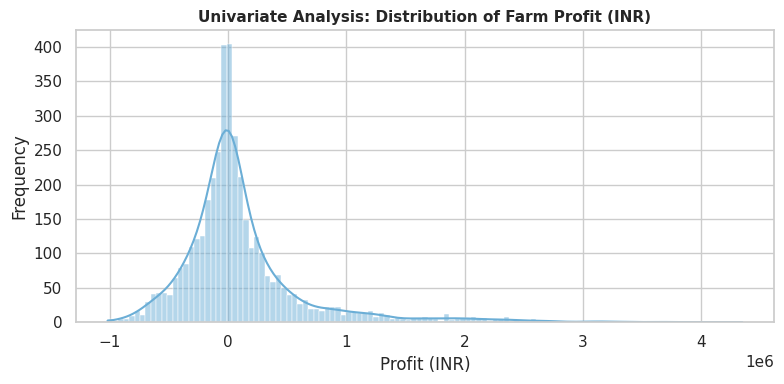

In [60]:
# Profit Distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Profit_INR', kde=True, color='#6baed6')
plt.title('Univariate Analysis: Distribution of Farm Profit (INR)', fontsize=11, fontweight='bold')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

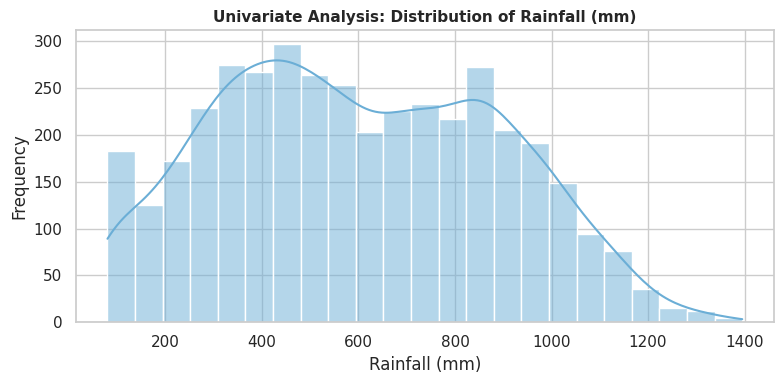

In [61]:
# Rainfall Distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Rainfall_mm', kde=True, color='#6baed6')
plt.title('Univariate Analysis: Distribution of Rainfall (mm)', fontsize=11, fontweight='bold')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
### Bivariate Analysis
Examining the direct relationships between season types, crop yields, financial returns, and resource utilization.

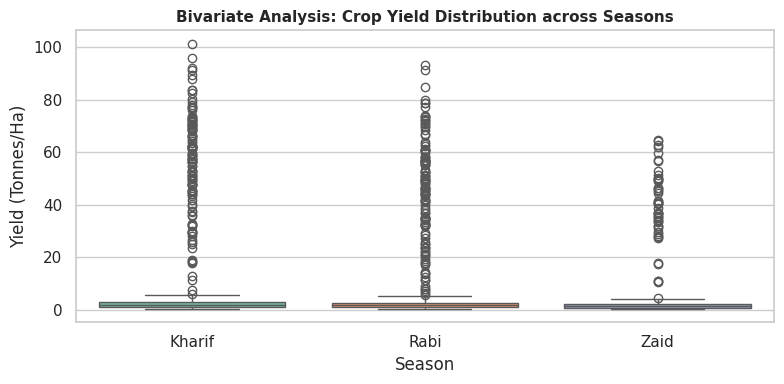

In [62]:
# Seasonal Yield Distribution
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', palette='Set2')
plt.title('Bivariate Analysis: Crop Yield Distribution across Seasons', fontsize=11, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

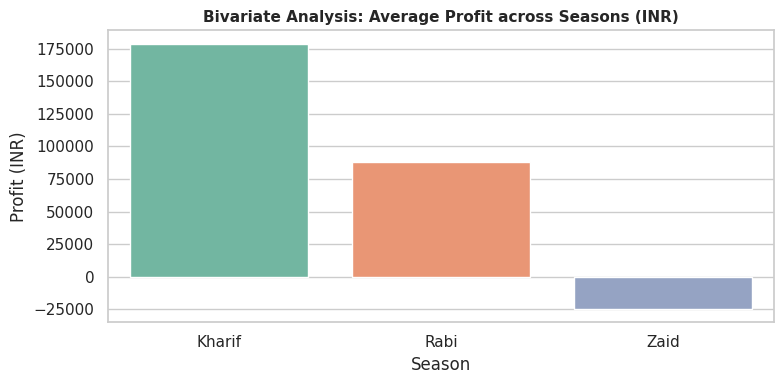

In [63]:
# Seasonal Average Profit
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Season', y='Profit_INR', estimator=np.mean, errorbar=None, hue='Season', palette='Set2')
plt.title('Bivariate Analysis: Average Profit across Seasons (INR)', fontsize=11, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

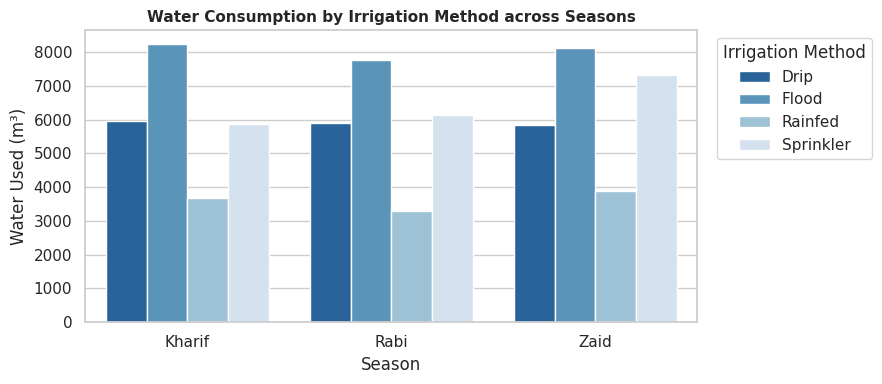

In [64]:
# Bivariate - Irrigation Method vs. Water Usage
plt.figure(figsize=(9, 4))
sns.barplot(data=df, x='Season', y='Water_Used_m3', hue='Irrigation_Method', errorbar=None, palette='Blues_r')
plt.title('Water Consumption by Irrigation Method across Seasons', fontsize=11, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [65]:
# Irrigation Method Efficiency Summary Table
irr_summary = df.groupby('Irrigation_Method').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
}).reset_index()

print("Irrigation Efficiency Comparison:")
display(irr_summary.round(2))

Irrigation Efficiency Comparison:


,Irrigation_Method,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
0,Drip,5918.75,6.27,219626.00
1,Flood,8026.47,3.44,73354.02
2,Rainfed,3549.55,7.56,79050.37
3,Sprinkler,6208.26,4.67,91121.08


Average Profit by Crop (INR):


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


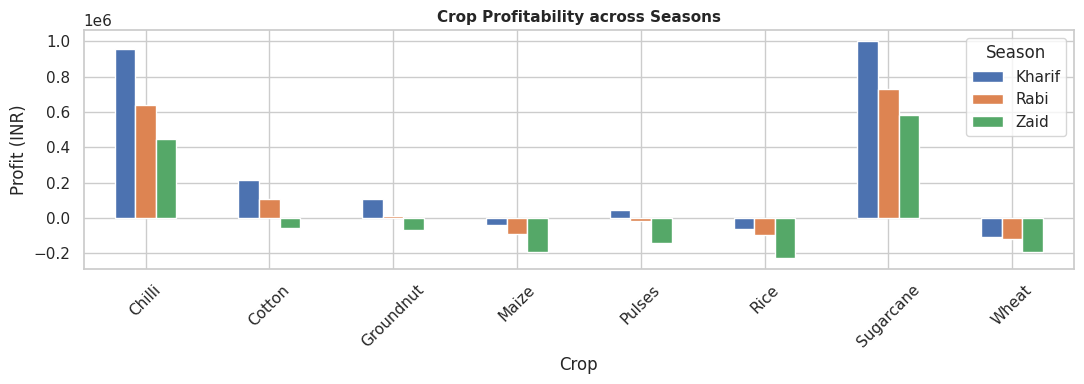

In [66]:
# Crop-wise Profitability Breakdown
crop_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean')
print("Average Profit by Crop (INR):")
display(crop_profit.round(2))

crop_profit.plot(kind='bar', figsize=(11, 4))
plt.title('Crop Profitability across Seasons', fontsize=11, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

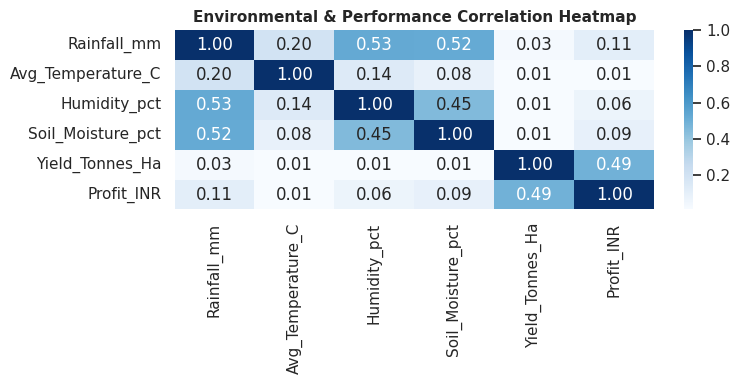

In [67]:
# Correlation Heatmap
plt.figure(figsize=(8, 4))
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha', 'Profit_INR']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='Blues', fmt=".2f", cbar=True)
plt.title('Environmental & Performance Correlation Heatmap', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [68]:
# Statistical Validation (One-Way ANOVA)

kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR']

f_stat, p_val = stats.f_oneway(kharif_profit, rabi_profit, zaid_profit)

print("--- One-Way ANOVA Test for Profit across Seasons ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value    : {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion : The difference in profit across seasons is statistically significant (p < 0.05).")
else:
    print("Conclusion : No statistically significant difference detected.")

--- One-Way ANOVA Test for Profit across Seasons ---
F-Statistic: 34.2918
P-Value    : 1.7124e-15
Conclusion : The difference in profit across seasons is statistically significant (p < 0.05).


---
### Key Findings & Strategic Recommendations

* **Seasonal Earnings Disparity:** Kharif generates the highest average profit (₹1,78,915), supported by monsoon rainfall. Rabi maintains consistent yields with ₹87,689 average profit. Zaid records an average loss (-₹24,805) driven by high irrigation costs during peak summer temperatures.
* **Statistical Validation:** A One-Way ANOVA test confirms that seasonal profit differences are statistically significant ($F = 34.29$, $p = 1.71 \times 10^{-15}$).
* **Crop Economics:** Commercial crops like Sugarcane (₹8,17,188 avg profit) and Chilli (₹7,50,878 avg profit) drive farm returns, while staple grains (Wheat and Rice) face tighter margins under high input costs.
* **Irrigation Efficiency:** Drip irrigation delivers the highest profitability (₹2,19,626) with superior water efficiency (6.27 t/1,000 m³). Flood irrigation consumes the most water (~8,026 m³) but yields lower returns (₹73,354).

#### Recommendations:
1. **Mitigate Summer Deficits:** Discourage high-water crops during Zaid; focus on drought-resilient legumes or protected cultivation.
2. **Promote Drip Irrigation:** Transitioning from flood to drip irrigation cuts water usage by ~25% and significantly boosts net margins.
3. **Targeted Kharif Pest Management:** Pre-monsoon pest surveillance should be deployed to prevent yield loss during high-humidity windows (54.5% risk peak).